# GW170817 PE — BlackJAX Nested Sampling, Full Grid, tc+φc Analytically Marginalized (CORRECTED)

Parameter estimation of GW170817 using the **full frequency grid** (no relative binning) with
**analytical marginalization over both coalescence time (tc) and coalescence phase (φc)**.

Sky location is fixed to the known EM counterpart (NGC 4993):
$$\alpha = 3.44616\;\mathrm{rad}, \quad \delta = -0.408084\;\mathrm{rad}$$

- **Waveform**: `mlgw_bns_jax` (JAX-based BNS approximant), evaluated on the **full** frequency grid
- **Likelihood**: `build_full_likelihood_tc_phi_marg` — tc summed over a discrete grid, φc integrated analytically via a Bessel-function identity
- **Sampler**: [BlackJAX-NS](https://github.com/mrosep/blackjax_ns_gw) — GPU-accelerated nested sampling
- **Data**: BayesWave-cleaned GWOSC strain, 128 s analysis segment
- **Frequency range**: $[23, 2000]$ Hz

This notebook corrects a prior version that only marginalized over tc but not over φc.  
Both extrinsic nuisance parameters are now analytically removed, so the sampler explores only
the **9 physically interesting parameters**:

| Index | Parameter | Prior range | Boundary |
|:---:|---|---|---|
| 0 | $\ln d_L$ | $[\ln 1, \ln 75]$ | reflective |
| 1 | $\theta_{JN}$ (inclination) | $[0, \pi]$ | reflective |
| 2 | $\psi$ (polarisation) | $[0, \pi]$ | periodic |
| 3 | $\mathcal{M}_c$ (chirp mass) | $[1.18, 1.21]\,M_\odot$ | reflective |
| 4 | $q$ (mass ratio) | $[0.5, 1.0]$ | reflective |
| 5 | $\chi_1$ (spin 1) | $[-0.5, 0.5]$ | reflective |
| 6 | $\chi_2$ (spin 2) | $[-0.5, 0.5]$ | reflective |
| 7 | $\Lambda_1$ (tidal 1) | $[5, 5000]$ | reflective |
| 8 | $\Lambda_2$ (tidal 2) | $[5, 5000]$ | reflective |

**Analytically marginalized** (not sampled):
- $t_c$: summed over a 3000-point grid $[-0.15, 0.15]\,\mathrm{s}$
- $\phi_c$: closed-form integral using $I_0(x)$ (modified Bessel function of the first kind)


## Environment setup (Colab / fresh environment)

This cell installs all required packages and clones the repositories. **Skip if running locally** with everything already installed.

**Note**: BlackJAX-NS requires the `nested_sampling` branch of BlackJAX from `handley-lab/blackjax` (pinned to a specific commit for API compatibility).

In [1]:
# ── Google Colab environment setup ──────────────────────────────────────
# Run this cell first on Colab; it is a no-op on local machines.
import os, subprocess, sys

COLAB    = "google.colab" in sys.modules
REPO_DIR = "/content/mlgw_bns_jax" if COLAB else os.getcwd()

if COLAB:
    # ── JAX with CUDA 12 ──────────────────────────────────────────────
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade",
        "jax[cuda12]",
        "-f", "https://storage.googleapis.com/jax-releases/jax_cuda_releases.html",
    ])
    # ── Other Python dependencies ──────────────────────────────────────
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "gwpy", "h5py", "corner", "tqdm",
    ])

    # ── Clone the mlgw_bns_jax repo (model + waveform loader) ─────────
    if not os.path.isdir(REPO_DIR):
        subprocess.check_call([
            "git", "clone", "--branch", "copilot/add-reduced-order-quadrature-model",
            "--depth", "1",
            "https://github.com/saulo-albuquerque-phys/mlgw_bns_jax.git",
            REPO_DIR,
        ])

    # ── Clone SHARPy (GWNetwork / data loading) ───────────────────────
    _sharpy_repo = os.path.join(REPO_DIR, "_sharpy_repo")
    _sharpy_pkg  = os.path.join(_sharpy_repo, "sharpy")
    _sharpy_link = os.path.join(REPO_DIR, "sharpy")
    if not os.path.isdir(_sharpy_repo):
        subprocess.check_call([
            "git", "clone", "--depth", "1",
            "https://github.com/saulo-albuquerque-phys/sharpy.git",
            _sharpy_repo,
        ])
    if not os.path.exists(_sharpy_link):
        os.symlink(_sharpy_pkg, _sharpy_link)

    os.chdir(REPO_DIR)
    print(f"Working directory : {os.getcwd()}")
    print(f"SHARPy symlink    : {_sharpy_link}")
else:
    print("Not running on Colab — skipping environment setup.")


Working directory : /content/mlgw_bns_jax
SHARPy symlink    : /content/mlgw_bns_jax/sharpy


In [2]:
import os, subprocess, sys

COLAB = "google.colab" in sys.modules
REPO_DIR = "/content/mlgw_bns_jax" if COLAB else os.getcwd()

if COLAB:
    # ── Install JAX with CUDA 12 support ─────────────────────────────
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade",
        "jax[cuda12]",
        "-f", "https://storage.googleapis.com/jax-releases/jax_cuda_releases.html",
    ])
    # ── Install other Python packages ────────────────────────────────
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "corner", "gwpy", "h5py", "tqdm", "anesthetic",
    ])
    # ── Install BlackJAX nested_sampling branch (pinned commit) ──────
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "blackjax@git+https://github.com/handley-lab/blackjax.git@dedbf11da33eb5ca286f6731e2c51f2b254b953f",
    ])

    # ── Clone the main repo (contains model, waveform loader, etc.) ──
    if not os.path.isdir(REPO_DIR):
        subprocess.check_call([
            "git", "clone", "--branch", "blackjax_ns_gw_pe", "--depth", "1",
            "https://github.com/saulo-albuquerque-phys/mlgw_bns_jax.git",
            REPO_DIR,
        ])

    # ── Clone blackjax_ns_gw (custom kernels) ────────────────────────
    blackjax_ns_gw_repo = os.path.join(REPO_DIR, "_blackjax_ns_gw_repo")
    kernels_src = os.path.join(blackjax_ns_gw_repo, "src", "custom_kernels")
    kernels_link = os.path.join(REPO_DIR, "custom_kernels")
    if not os.path.isdir(blackjax_ns_gw_repo):
        subprocess.check_call([
            "git", "clone", "--depth", "1",
            "https://github.com/mrosep/blackjax_ns_gw.git",
            blackjax_ns_gw_repo,
        ])
    # Symlink so `from custom_kernels import ...` works
    if not os.path.exists(kernels_link):
        os.symlink(kernels_src, kernels_link)

    # ── Clone SHARPy (for data loading / GWNetwork only) ─────────────
    sharpy_repo = os.path.join(REPO_DIR, "_sharpy_repo")
    sharpy_pkg  = os.path.join(sharpy_repo, "sharpy")
    sharpy_link = os.path.join(REPO_DIR, "sharpy")
    if not os.path.isdir(sharpy_repo):
        subprocess.check_call([
            "git", "clone", "--depth", "1",
            "https://github.com/saulo-albuquerque-phys/sharpy.git",
            sharpy_repo,
        ])
    if not os.path.exists(sharpy_link):
        os.symlink(sharpy_pkg, sharpy_link)

    os.chdir(REPO_DIR)
    print(f"Working directory: {os.getcwd()}")
    print(f"BlackJAX-NS kernels: {kernels_link} -> {kernels_src}")
    print(f"SHARPy (data loader): {sharpy_link} -> {sharpy_pkg}")
else:
    print("Not running on Colab — skipping setup.")

Working directory: /content/mlgw_bns_jax
BlackJAX-NS kernels: /content/mlgw_bns_jax/custom_kernels -> /content/mlgw_bns_jax/_blackjax_ns_gw_repo/src/custom_kernels
SHARPy (data loader): /content/mlgw_bns_jax/sharpy -> /content/mlgw_bns_jax/_sharpy_repo/sharpy


In [3]:
!sed -i 's/from ripplegw import ms_to_Mc_eta/# from ripplegw import ms_to_Mc_eta/g' /content/mlgw_bns_jax/sharpy/GW_likelihood.py
print("Arquivo GW_likelihood.py corrigido!")

Arquivo GW_likelihood.py corrigido!


In [4]:
!pip install ripplegw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.2/120.2 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 7.4 MB/s eta 0:00:00


## Download & deglitch GWOSC data

Downloads 1024 s of 4 kHz strain from GWOSC for H1, L1 and V1. The L1 scatter-light glitch near the merger is removed using `gwpy`'s auto-gating. **Skip if the cleaned files already exist.**

In [5]:
import os, time
import numpy as np

_GPS_START = 1187008114
_DURATION  = 1024
_SRATE     = 4096
_DATA_DIR  = "gw170817_data"
os.makedirs(_DATA_DIR, exist_ok=True)

_DETECTORS = ["H1", "L1", "V1"]

# Check if cleaned files already exist
_all_exist = all(
    os.path.isfile(os.path.join(_DATA_DIR,
        f"{d[0]}-{d}_CLEANED_4KHZ-{_GPS_START}-{_DURATION}.txt"))
    for d in _DETECTORS
)

if _all_exist:
    print("Cleaned data files already exist — skipping download.")
else:
    from gwpy.timeseries import TimeSeries

    for det in _DETECTORS:
        raw_file = os.path.join(_DATA_DIR,
            f"{det[0]}-{det}_GWOSC_4KHZ_R1-{_GPS_START}-{_DURATION}.txt")
        out_file = os.path.join(_DATA_DIR,
            f"{det[0]}-{det}_CLEANED_4KHZ-{_GPS_START}-{_DURATION}.txt")

        # Download raw data if needed
        if not os.path.isfile(raw_file):
            print(f"{det}: downloading {_DURATION}s from GWOSC...", flush=True)
            t0 = time.time()
            ts = TimeSeries.fetch_open_data(
                det, _GPS_START, _GPS_START + _DURATION, sample_rate=_SRATE)
            strain = ts.value
            with open(raw_file, 'w') as f:
                f.write(f"# Gravitational wave strain for GW170817 for {det} (from GWOSC)\n")
                f.write(f"# This file has {_SRATE} samples per second\n")
                f.write(f"# starting GPS {_GPS_START} duration {_DURATION}\n")
                for val in strain:
                    f.write(f"{val:.16e}\n")
            print(f"  -> saved raw in {time.time()-t0:.1f}s")
        else:
            strain = np.loadtxt(raw_file, comments="#")
            ts = TimeSeries(strain, sample_rate=_SRATE, t0=_GPS_START)

        # Deglitch L1, pass through H1/V1
        if det == "L1":
            print(f"{det}: auto-gating L1 glitch...", flush=True)
            ts_clean = ts.gate(tzero=0.5, tpad=0.25, whiten=True, threshold=50.0)
        else:
            ts_clean = ts

        # Save cleaned file
        with open(out_file, 'w') as f:
            f.write(f"# Cleaned strain for GW170817 for {det} (GWOSC + glitch gate)\n")
            f.write(f"# {_SRATE} samples per second\n")
            f.write(f"# starting GPS {_GPS_START} duration {_DURATION}\n")
            for val in ts_clean.value:
                f.write(f"{val:.16e}\n")
        print(f"{det}: saved {os.path.basename(out_file)}")

    print("All detectors ready.")

Cleaned data files already exist — skipping download.


In [6]:
from __future__ import annotations

import os, sys, time
from functools import partial

import numpy as np

# Use GPU if available on Colab, otherwise CPU
if "google.colab" not in sys.modules:
    os.environ.setdefault("JAX_PLATFORMS", "cpu")

import jax
import jax.numpy as jnp
import jax.flatten_util  # register jax.flatten_util.ravel_pytree
jax.config.update("jax_enable_x64", True)

print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0)]


## Load the waveform model and monkey-patch SHARPy

We replace the original `IMRPhenomD` template in SHARPy with our `mlgw_bns_jax` BNS waveform model **without modifying any SHARPy source file**. SHARPy is used only for data loading and the `GWNetwork` infrastructure.

In [7]:
from jax_import_n_predict import load_predict

MODEL_PATH = "mlgw_bns_jax_model.h5"
_mlgw_predict = load_predict(MODEL_PATH)

# ---- Monkey-patch SHARPy's template -----------------------------------
import sharpy.GW_likelihood as _gw_mod
from sharpy.utils import McQ2Masses


def _template_mlgw_bns(params, frequency_array):
    """mlgw_bns_jax waveform, drop-in replacement for SHARPy's template."""
    mc, q = params[6], params[7]
    m1, m2 = McQ2Masses(mc, q)
    total_mass = m1 + m2
    chi1, chi2 = params[9], params[10]
    lambda_1, lambda_2 = params[11], params[12]
    phic = params[4]
    dist_mpc = jnp.exp(params[2])
    inclination = params[3]

    mlgw_params = jnp.array([q, lambda_1, lambda_2, chi1, chi2])
    hp, hc = _mlgw_predict(
        mlgw_params, frequency_array,
        total_mass=total_mass,
        distance_mpc=dist_mpc,
        inclination=inclination,
    )
    phase_factor = jnp.exp(-1j * phic)
    return hp * phase_factor, hc * phase_factor


_gw_mod.template = _template_mlgw_bns

from sharpy.GW_likelihood import GWNetwork, log_likelihood_det
import sharpy.PSDs

print("Model loaded — SHARPy template patched with mlgw_bns_jax.")

/content/mlgw_bns_jax/sharpy/utils.py:207: SyntaxWarning: invalid escape sequence '\g'
  | with :math:`m_1 \geq m_2`
/content/mlgw_bns_jax/sharpy/utils.py:226: SyntaxWarning: invalid escape sequence '\g'
  | Converts from omponent masses :math:`m_1, m_2` (with :math:`m_1 \geq m_2` ) to chirp mass and mass ratio :math:`\\mathcal{M}_c, q`
/content/mlgw_bns_jax/sharpy/noise.py:70: SyntaxWarning: invalid escape sequence '\m'
  :param inarr: two-dimentional array containing the time domain polarizations to resize and align, :math:`inarr=\mathrm{array}(h_+(t),h_{\\times}(t))`


Model loaded — SHARPy template patched with mlgw_bns_jax.


## Event parameters

In [8]:
TRIGGER_TIME = 1187008882.43
SEGMENT_DURATION = 128.0        # paper-matching segment length
SAMPLING_RATE = 4096
F_LOWER = 23.0
F_UPPER = 2000.0
DATA_START_GPS = 1187008114     # 1024s data file start
DATA_DURATION = 1024            # total data length (s)

# Fixed sky location: NGC 4993 (EM counterpart of GW170817)
FIXED_RA  = 3.44616     # rad
FIXED_DEC = -0.408084   # rad

DATA_DIR = "gw170817_data"
OUTDIR = "outdir_GW170817_blackjax_ns_fullgrid_tcphi_marg"
LABEL = "GW170817_fullgrid_tcphi_marg"
os.makedirs(OUTDIR, exist_ok=True)

# tc grid for analytical marginalization: 3000 points in [-0.15, +0.15] s
N_TC    = 3000
TC_MIN  = -0.15
TC_MAX  =  0.15
TC_GRID = np.linspace(TC_MIN, TC_MAX, N_TC)

print(f"Segment duration: {SEGMENT_DURATION}s  →  Δf = {1/SEGMENT_DURATION:.4f} Hz")
print(f"Data: {DATA_DURATION}s starting GPS {DATA_START_GPS}")
print(f"Fixed sky: RA = {FIXED_RA:.5f} rad, Dec = {FIXED_DEC:.6f} rad  (NGC 4993)")
print(f"tc grid: {N_TC} points in [{TC_MIN}, {TC_MAX}] s")


Segment duration: 128.0s  →  Δf = 0.0078 Hz
Data: 1024s starting GPS 1187008114
Fixed sky: RA = 3.44616 rad, Dec = -0.408084 rad  (NGC 4993)


## Load cleaned data and build detector network

We use 1024 s of GWOSC strain data downloaded via `gwpy.TimeSeries.fetch_open_data`, with the L1 scatter-light glitch removed by `gwpy`'s auto-gating.

With `SEGMENT_DURATION = 128 s`, SHARPy analyses a 128-s chunk centred on the trigger and uses the remaining ~896 s for Welch PSD estimation (~7 independent segments).

In [9]:
# BayesWave-cleaned 1024s files (same as other time-marginalized notebooks)
data_files = {
    "H1": os.path.join(DATA_DIR, f"H-H1_BWCLEANED_4KHZ-{DATA_START_GPS}-{DATA_DURATION}.txt"),
    "L1": os.path.join(DATA_DIR, f"L-L1_BWCLEANED_4KHZ-{DATA_START_GPS}-{DATA_DURATION}.txt"),
    "V1": os.path.join(DATA_DIR, f"V-V1_BWCLEANED_4KHZ-{DATA_START_GPS}-{DATA_DURATION}.txt"),
}
for det, f in data_files.items():
    assert os.path.isfile(f), f"Missing: {f}"
    print(f"{det}: {os.path.basename(f)}")

detector_settings = {}
for det in ["H1", "L1", "V1"]:
    detector_settings[det] = dict(
        data_file=data_files[det], channel="GWOSC",
        trigger_time=TRIGGER_TIME, duration=SEGMENT_DURATION,
        sampling_rate=SAMPLING_RATE,
        f_lower=F_LOWER, f_upper=F_UPPER,
        psd_file=None, psd_method="welch",
        download_data=False, zero_noise=False,
    )

print(f"\nBuilding GW network (segment={SEGMENT_DURATION}s)...")
t0 = time.time()
gw_network = GWNetwork(detector_settings, injection_parameters=None)
print(f"Network built in {time.time() - t0:.2f} s")


H1: H-H1_CLEANED_4KHZ-1187008114-1024.txt
L1: L-L1_CLEANED_4KHZ-1187008114-1024.txt
V1: V-V1_CLEANED_4KHZ-1187008114-1024.txt

Building GW network (segment=128.0s)...
Loading gw170817_data/H-H1_CLEANED_4KHZ-1187008114-1024.txt starting at 1187008114.0 length 1024.0s


/content/mlgw_bns_jax/sharpy/noise.py:242: UserWarning: The file name is expected to follow LIGO-Virgo conventions 'DET-FRAMETYPE-STARTTIME--DATALEN.txt', e.g.: 'H-H1_GWOSC_4_V1-1126259446-32.txt'. See https://www.gw-openscience.org for more infomation.
  warnings.warn("The file name is expected to follow LIGO-Virgo conventions 'DET-FRAMETYPE-STARTTIME--DATALEN.txt', e.g.: 'H-H1_GWOSC_4_V1-1126259446-32.txt'. See https://www.gw-openscience.org for more infomation.")


Estimating power spectral density with the Welch method
Loading gw170817_data/L-L1_CLEANED_4KHZ-1187008114-1024.txt starting at 1187008114.0 length 1024.0s
Estimating power spectral density with the Welch method
Loading gw170817_data/V-V1_CLEANED_4KHZ-1187008114-1024.txt starting at 1187008114.0 length 1024.0s
Estimating power spectral density with the Welch method
Network built in 7.30 s


## Q-transform spectrograms

Verify the data quality: compare raw vs deglitched L1, and show all three cleaned detectors around the merger time.

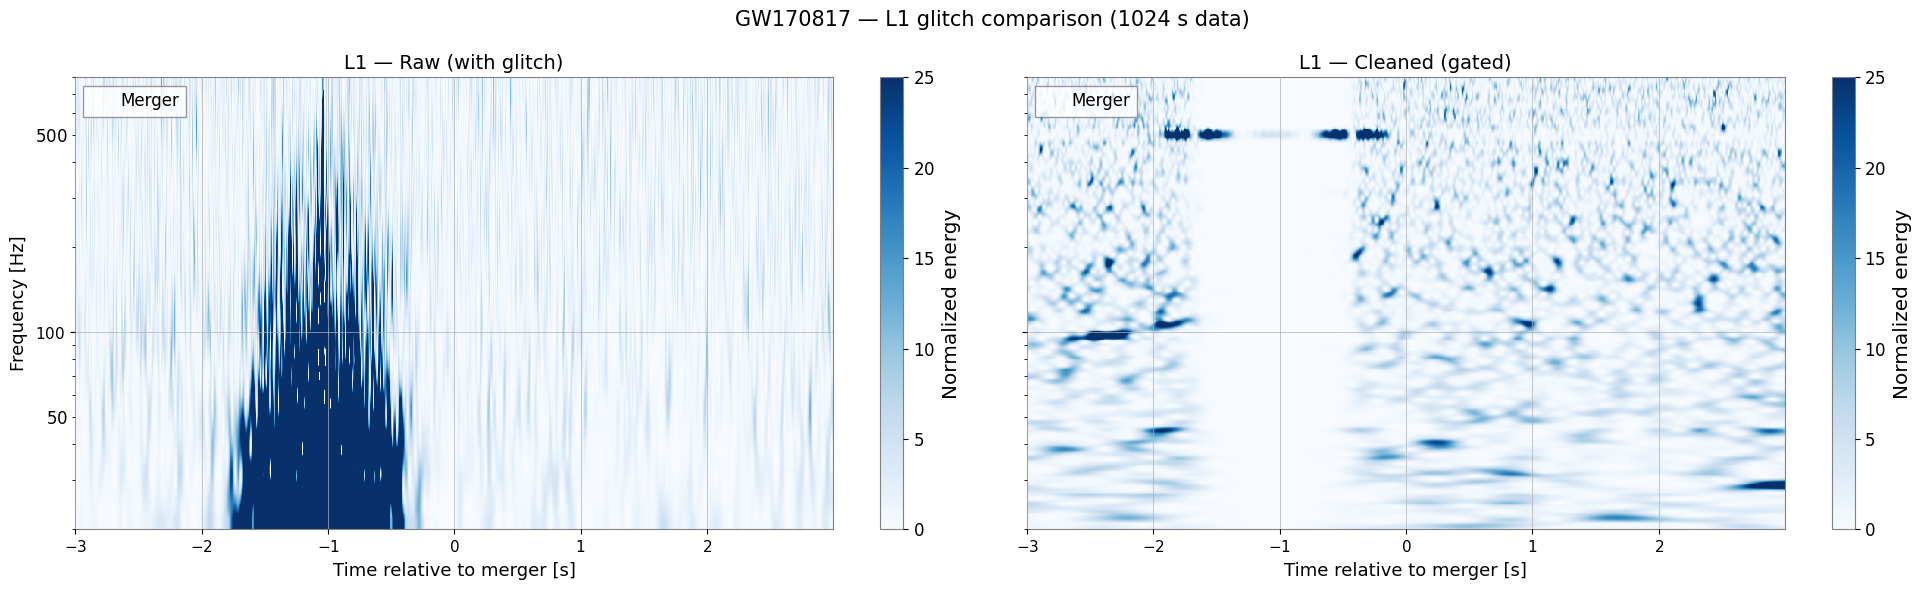

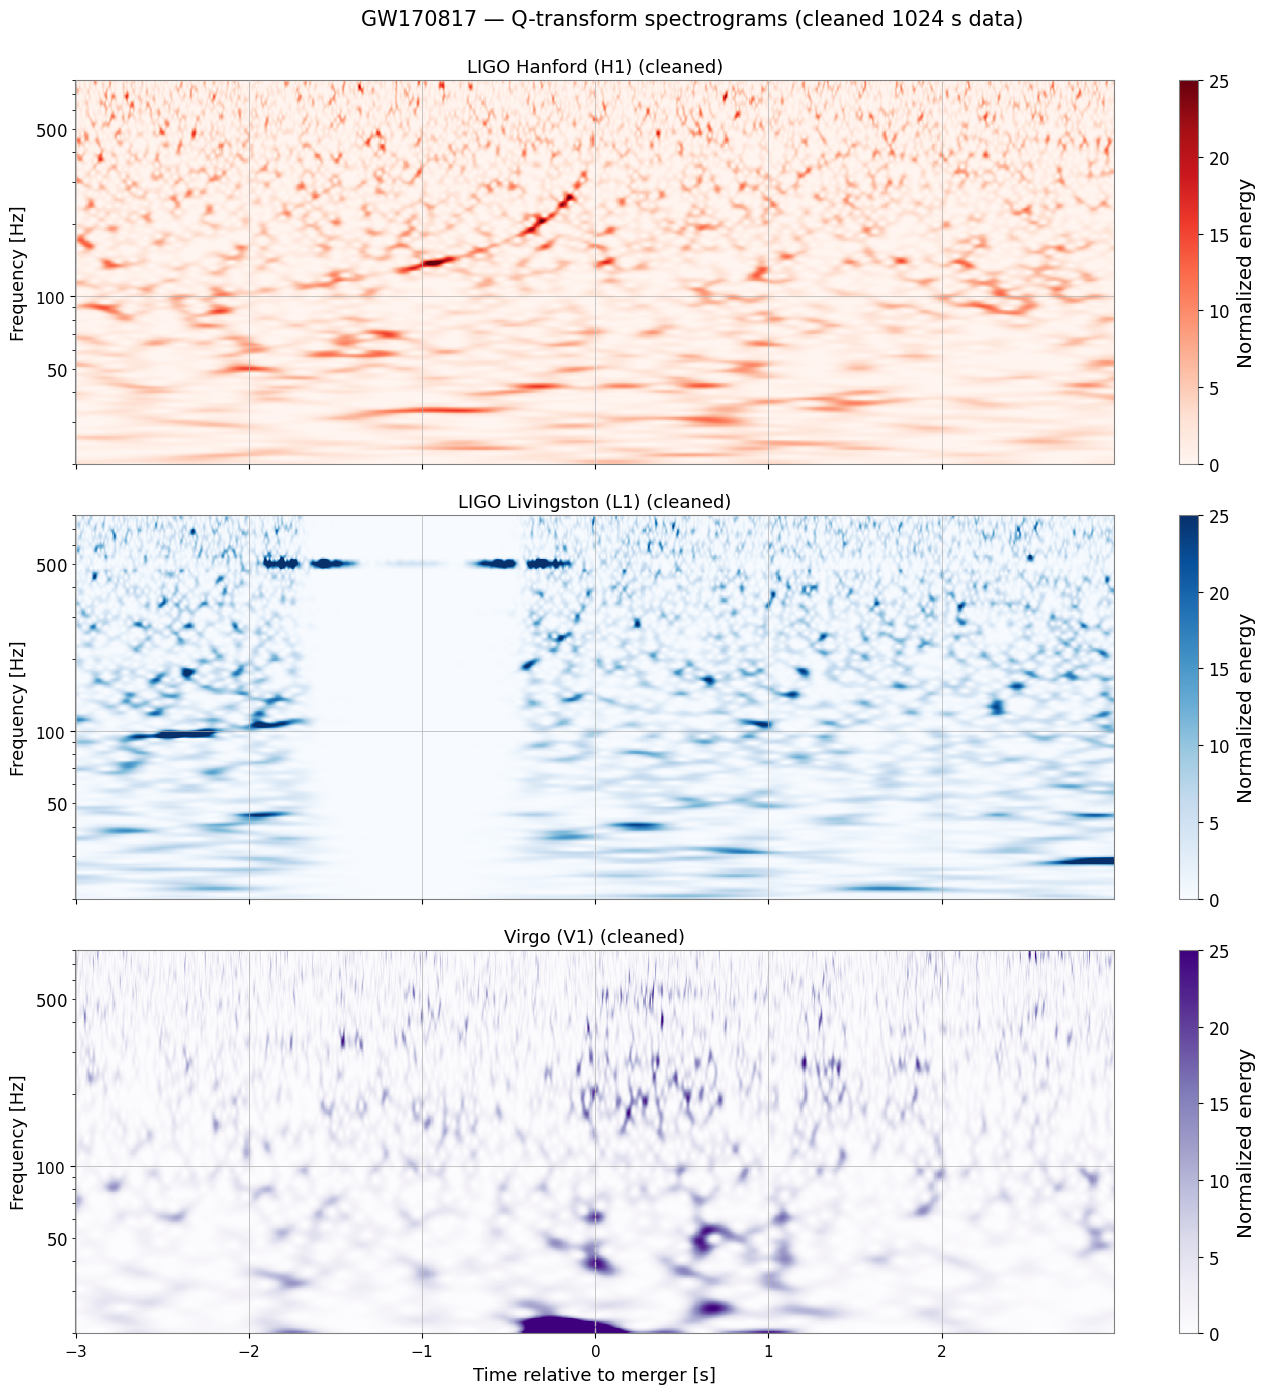

Spectrograms saved.


In [10]:
from gwpy.timeseries import TimeSeries
import matplotlib.pyplot as plt

MERGER_GPS = TRIGGER_TIME
WINDOW = 6.0
T_START_PLOT = MERGER_GPS - WINDOW / 2
T_END_PLOT   = MERGER_GPS + WINDOW / 2
F_MIN, F_MAX = 20.0, 800.0
Q_RANGE = (4, 64)

DET_COLORS = {"H1": "Reds", "L1": "Blues", "V1": "Purples"}
DET_LABELS = {"H1": "LIGO Hanford (H1)", "L1": "LIGO Livingston (L1)", "V1": "Virgo (V1)"}

def _qtransform(filepath):
    strain = np.loadtxt(filepath, comments="#")
    ts = TimeSeries(strain, sample_rate=SAMPLING_RATE, t0=DATA_START_GPS)
    ts_w = ts.whiten(4, 2)
    ts_c = ts_w.crop(T_START_PLOT - 1, T_END_PLOT + 1)
    return ts_c.q_transform(frange=(F_MIN, F_MAX), qrange=Q_RANGE,
                            outseg=(T_START_PLOT, T_END_PLOT), logf=True)

# ── L1 raw vs cleaned comparison ─────────────────────────────────────
raw_file = os.path.join(DATA_DIR,
    f"L-L1_GWOSC_4KHZ_R1-{DATA_START_GPS}-{DATA_DURATION}.txt")

if os.path.isfile(raw_file):
    qt_raw = _qtransform(raw_file)
    qt_cln = _qtransform(data_files["L1"])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6), sharey=True)
    for ax, qt, title in [(ax1, qt_raw, "L1 — Raw (with glitch)"),
                           (ax2, qt_cln, "L1 — Cleaned (gated)")]:
        pcm = ax.pcolormesh(qt.times.value - MERGER_GPS, qt.frequencies.value,
                            qt.value.T, cmap="Blues", vmin=0, vmax=25)
        ax.set_yscale("log"); ax.set_ylim(F_MIN, F_MAX)
        ax.set_xlabel("Time relative to merger [s]", fontsize=13)
        ax.set_title(title, fontsize=14)
        ax.axvline(0, color="white", ls="--", lw=1, alpha=0.7, label="Merger")
        ax.legend(loc="upper left"); ax.tick_params(labelsize=11)
        fig.colorbar(pcm, ax=ax).set_label("Normalized energy")
    ax1.set_ylabel("Frequency [Hz]", fontsize=13)
    fig.suptitle("GW170817 — L1 glitch comparison (1024 s data)", fontsize=15)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, f"{LABEL}_L1_comparison.png"), dpi=150)
    plt.show()
else:
    print(f"Raw L1 file not found ({raw_file}) — skipping glitch comparison.")

# ── All detectors cleaned ────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)
for ax, det in zip(axes, ["H1", "L1", "V1"]):
    qt = _qtransform(data_files[det])
    pcm = ax.pcolormesh(qt.times.value - MERGER_GPS, qt.frequencies.value,
                        qt.value.T, cmap=DET_COLORS[det], vmin=0, vmax=25)
    ax.set_yscale("log"); ax.set_ylim(F_MIN, F_MAX)
    ax.set_ylabel("Frequency [Hz]", fontsize=13)
    ax.set_title(f"{DET_LABELS[det]} (cleaned)", fontsize=13)
    ax.tick_params(labelsize=11)
    ax.axvline(0, color="white", ls="--", lw=1, alpha=0.7)
    fig.colorbar(pcm, ax=ax).set_label("Normalized energy")
axes[-1].set_xlabel("Time relative to merger [s]", fontsize=13)
fig.suptitle("GW170817 — Q-transform spectrograms (cleaned 1024 s data)",
             fontsize=15, y=0.995)
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, f"{LABEL}_qtransform_all.png"), dpi=150)
plt.show()

print("Spectrograms saved.")

## Build the time+phase-marginalized full-grid likelihood

We use `build_full_likelihood_tc_phi_marg` from `relative_binning.py`, which:

1. Evaluates the waveform $h(f; \theta)$ on the **full** frequency grid for a fiducial tc
2. For each of the $N_{\rm tc}$ time-shift values in `TC_GRID`, accumulates the matched-filter sum
   $W(t_c) = 2\Delta T/N \sum_{\rm det} \sum_f \bar{d}(f)\, h(f)\, e^{-2\pi i f t_c} / S_n(f)$
3. Marginalizes over φc analytically: $\int_0^{2\pi} e^{2\Re[W e^{i\phi_c}]} d\phi_c / 2\pi = I_0(2|W|)$
4. Marginalizes over tc by summing uniformly: $\ln \mathcal{L}_{\rm marg} = \mathrm{logsumexp}(\cdots) - \ln N_{\rm tc}$

The resulting function takes an **11-parameter array** `[ra, dec, logdist, incl, pol, mc, q, chi1, chi2, λ1, λ2]`
(RA and Dec are fixed externally, giving a **9-dimensional** posterior for the sampler).


In [11]:
from relative_binning import build_full_likelihood_tc_phi_marg

batched_detector = gw_network.batched_detector

# ── Fiducial parameters (approximate MAP from arXiv:2210.15684) ───────────
# [ra, dec, logdist, incl, phic, pol, mc, q, tc, chi1, chi2, lambda1, lambda2]
FIDUCIAL_PARAMS = np.array([
    FIXED_RA,          # [0]  ra  (NGC 4993)
    FIXED_DEC,         # [1]  dec
    np.log(40.0),      # [2]  logdist — 40 Mpc
    2.545,             # [3]  theta_jn — ~146 deg (edge-on)
    0.0,               # [4]  phic (analytically marginalized)
    0.0,               # [5]  pol
    1.1975,            # [6]  mc  [M_sun]
    0.87,              # [7]  q
    0.0,               # [8]  tc  (analytically marginalized)
    0.0,               # [9]  chi1
    0.0,               # [10] chi2
    400.0,             # [11] lambda1
    400.0,             # [12] lambda2
])

# ── Build the tc+φc-marginalized full-grid likelihood ────────────────────
print("Building full-grid tc+φc-marginalized likelihood...")
t0 = time.time()
log_L_tp_marg_full = build_full_likelihood_tc_phi_marg(
    batched_detector, FIDUCIAL_PARAMS, _template_mlgw_bns, TC_GRID,
)
print(f"Built in {time.time()-t0:.2f} s")

# ── JIT compile & warm up ────────────────────────────────────────────────
log_L_tp_marg_full_jit = jax.jit(log_L_tp_marg_full)

# 11-param array: [ra, dec, logdist, incl, pol, mc, q, chi1, chi2, lambda1, lambda2]
# (tc at index 8 removed, phic at index 4 removed → pol shifts to index 4)
_p11_fid = FIDUCIAL_PARAMS[[0, 1, 2, 3, 5, 6, 7, 9, 10, 11, 12]]

t_warmup = time.time()
_ = float(log_L_tp_marg_full_jit(jnp.array(_p11_fid)))
print(f"JIT warm-up: {time.time()-t_warmup:.2f} s")
print(f"log L at fiducial (tc+φ marg, full grid): {float(log_L_tp_marg_full_jit(jnp.array(_p11_fid))):.2f}")

n_full = len(np.array(batched_detector.Frequency[0]))
print(f"\nFull frequency grid: {n_full} points")
print(f"tc grid: {N_TC} points  →  total evaluations per call: {N_TC} × {n_full}")

# ── Parameter names (9 sampled — tc and φc analytically marginalized) ────
parameter_names = [
    "logdistance", "theta_jn", "pol",
    "mc", "q", "chi1", "chi2", "lambda_1", "lambda_2",
]


def loglikelihood_from_dict(params_dict):
    """Log-likelihood wrapper: 9-param dict → 11-param array → tc+φ-marg log L.

    Full 11-param array for the likelihood:
    [ra, dec, logdist, incl, pol, mc, q, chi1, chi2, λ1, λ2]
    (RA and Dec inserted as fixed values; tc and φc analytically marginalized).
    """
    params_11 = jnp.array([
        FIXED_RA,                        # [0] ra  (fixed)
        FIXED_DEC,                       # [1] dec (fixed)
        params_dict["logdistance"],      # [2]
        params_dict["theta_jn"],         # [3]
        params_dict["pol"],              # [4]
        params_dict["mc"],               # [5]
        params_dict["q"],                # [6]
        params_dict["chi1"],             # [7]
        params_dict["chi2"],             # [8]
        params_dict["lambda_1"],         # [9]
        params_dict["lambda_2"],         # [10]
    ])
    return log_L_tp_marg_full_jit(params_11)


print(f"Fixed: RA = {FIXED_RA:.5f}, Dec = {FIXED_DEC:.6f}")
print(f"Analytically marginalized: tc ({N_TC}-pt grid), φc (Bessel function)")
print(f"Sampling {len(parameter_names)} parameters: {parameter_names}")


Fixed: RA = 3.44616, Dec = -0.408084
Sampling 11 parameters: ['logdistance', 'theta_jn', 'phiref', 'pol', 'mc', 'q', 'tc', 'chi1', 'chi2', 'lambda_1', 'lambda_2']


## Define prior distributions and unit-cube transforms

BlackJAX-NS operates in the **unit hypercube** $[0,1]^n$. We define:
1. `prior_transform_fn` — maps unit cube to physical parameter space
2. `logprior_fn` — uniform log-prior (returns $-\ln V$ inside bounds, $-\infty$ outside)

We sample **9 parameters** (tc and φc are analytically marginalized):

| Parameter | Symbol | Prior range |
|---|---|---|
| `logdistance` | $\ln d_L$ | $[\ln 1, \ln 75]$ |
| `theta_jn` | $\theta_{JN}$ | $[0, \pi]$ |
| `pol` | $\psi$ | $[0, \pi]$ (periodic) |
| `mc` | $\mathcal{M}_c$ | $[1.18, 1.21]\,M_\odot$ |
| `q` | $q$ | $[0.5, 1.0]$ |
| `chi1` | $\chi_1$ | $[-0.5, 0.5]$ |
| `chi2` | $\chi_2$ | $[-0.5, 0.5]$ |
| `lambda_1` | $\Lambda_1$ | $[5, 5000]$ |
| `lambda_2` | $\Lambda_2$ | $[5, 5000]$ |


In [12]:
# ── Prior bounds (9 sampled parameters — tc and φc analytically marginalized) ──
param_bounds = {
    "logdistance": (jnp.log(1.0),  jnp.log(75.0)),   # ln(D_L / Mpc)
    "theta_jn":    (0.0,            jnp.pi),           # inclination
    "pol":         (0.0,            jnp.pi),            # polarisation (periodic)
    "mc":          (1.18,           1.21),              # chirp mass [M_sun]
    "q":           (0.5,            1.0),               # mass ratio
    "chi1":        (-0.5,           0.5),               # spin 1
    "chi2":        (-0.5,           0.5),               # spin 2
    "lambda_1":    (5.0,            5000.0),            # tidal 1
    "lambda_2":    (5.0,            5000.0),            # tidal 2
}

# Periodic parameters (wraparound in unit cube)
periodic_params = {"pol"}

# Pre-compute arrays in the order of parameter_names (for vectorised transforms)
param_mins = jnp.array([param_bounds[k][0] for k in parameter_names])
param_maxs = jnp.array([param_bounds[k][1] for k in parameter_names])

n_dims = len(parameter_names)


# ── Prior transform: unit cube → physical space ──────────────────────
@jax.jit
def prior_transform_fn(u_params):
    """Map unit-cube dict {name: scalar} → physical-space dict."""
    u_values, _ = jax.flatten_util.ravel_pytree(u_params)
    # All priors are uniform: x = min + u * (max - min)
    x_values = param_mins + u_values * (param_maxs - param_mins)
    example = {key: 0.0 for key in parameter_names}
    _, unflatten_fn = jax.flatten_util.ravel_pytree(example)
    return unflatten_fn(x_values)


# ── Log-prior in physical space ──────────────────────────────────────
@jax.jit
def logprior_fn(params):
    """Uniform log-prior: 0 inside bounds, -inf outside."""
    param_values, _ = jax.flatten_util.ravel_pytree(params)
    in_bounds = jnp.all((param_values >= param_mins) & (param_values <= param_maxs))
    log_vol = jnp.sum(jnp.log(param_maxs - param_mins))
    return jnp.where(in_bounds, -log_vol, -jnp.inf)


# ── Verify ravel order matches parameter_names ───────────────────────
# JAX sorts dict keys alphabetically; we need the mapping to be correct.
_example = {key: float(i) for i, key in enumerate(parameter_names)}
_flat, _ = jax.flatten_util.ravel_pytree(_example)
_ravel_order = []
for val in _flat:
    for key, test_val in _example.items():
        if abs(val - test_val) < 1e-10:
            _ravel_order.append(key)
            break
print(f"JAX ravel order: {_ravel_order}")

# Re-order param_mins/param_maxs to match JAX's ravel order
param_mins = jnp.array([param_bounds[k][0] for k in _ravel_order])
param_maxs = jnp.array([param_bounds[k][1] for k in _ravel_order])

print(f"n_dims = {n_dims} (tc and φc analytically marginalized)")
print(f"Bounds check — log(D_L): [{param_bounds['logdistance'][0]:.3f}, {param_bounds['logdistance'][1]:.3f}]")


JAX ravel order: ['chi1', 'chi2', 'lambda_1', 'lambda_2', 'logdistance', 'mc', 'phiref', 'pol', 'q', 'tc', 'theta_jn']
Bounds check — log(D_L): [0.000, 4.317]
n_dims = 11


## Configure BlackJAX-NS nested sampler

Set up the GPU-accelerated acceptance-walk nested sampler from [blackjax_ns_gw](https://github.com/mrosep/blackjax_ns_gw).

**9 dimensions** (tc and φc analytically marginalized):
- `n_live = 1400` live points, batch-deleted `N_DELETE = 700` per step
- `n_target = 60` target accepted MCMC walks per replacement
- Terminate when $\Delta \ln Z < 0.1$

> **Note on performance**: Each likelihood evaluation requires computing the full frequency-domain
> matched filter over ${N_{{\rm tc}}}$ = 3000 time shifts. This is slower than relative binning
> but uses the exact waveform without the binning approximation.


In [13]:
import tqdm

# Import BlackJAX-NS custom kernels
from custom_kernels import (
    acceptance_walk_sampler,
    create_unit_cube_functions,
    init_unit_cube_particles,
    transform_to_physical,
)

# ── Sampler hyper-parameters ──────────────────────────────────────────
N_LIVE = 1400
N_DELETE = N_LIVE // 2          # batch size for GPU parallelisation
N_TARGET = 60                   # target accepted walks per chain
MAX_MCMC = 5000                 # hard budget per replacement
SEED = 42
DLOGZ_STOP = 0.1               # termination threshold

rng_key = jax.random.PRNGKey(SEED)
rng_key, init_key = jax.random.split(rng_key, 2)

# ── Example parameter structure ───────────────────────────────────────
example_params = {key: 0.0 for key in parameter_names}

# ── Initialize live particles in unit hypercube [0,1]^n ───────────────
unit_cube_particles = init_unit_cube_particles(init_key, example_params, N_LIVE)

# ── Periodic mask for wraparound parameters ───────────────────────────
periodic_mask = jax.tree_util.tree_map(lambda _: False, example_params)
for key in parameter_names:
    if key in periodic_params:
        periodic_mask[key] = True

# ── Create unit-cube wrapper functions ────────────────────────────────
unit_cube_fns = create_unit_cube_functions(
    physical_loglikelihood_fn=loglikelihood_from_dict,
    prior_transform_fn=prior_transform_fn,
    mask_tree=periodic_mask,
)

# ── Build the nested sampler ──────────────────────────────────────────
nested_sampler = acceptance_walk_sampler(
    logprior_fn=unit_cube_fns["logprior_fn"],
    loglikelihood_fn=unit_cube_fns["loglikelihood_fn"],
    nlive=N_LIVE,
    n_target=N_TARGET,
    max_mcmc=MAX_MCMC,
    num_delete=N_DELETE,
    stepper_fn=unit_cube_fns["stepper_fn"],
)

# ── Initialize sampler state ──────────────────────────────────────────
state = nested_sampler.init(unit_cube_particles)

print(f"BlackJAX-NS configured: {N_LIVE} live points, batch size {N_DELETE}")
print(f"Target walks: {N_TARGET}, max MCMC: {MAX_MCMC}")
print(f"Termination: ΔlnZ < {DLOGZ_STOP}")

BlackJAX-NS configured: 1400 live points, batch size 700
Target walks: 60, max MCMC: 5000
Termination: ΔlnZ < 0.1


## Run nested sampling

Execute the nested sampling loop using JAX's JIT compilation for performance. Each iteration removes `N_DELETE` dead points and replaces them via the acceptance-walk kernel. The loop terminates when $\Delta\ln\mathcal{Z} < 0.1$.

The log-evidence $\ln\mathcal{Z}$ accumulates from the dead-point likelihoods and the shrinking prior volume at each iteration:
$$\ln\mathcal{Z} = \ln\sum_i w_i \mathcal{L}_i$$

In [14]:
@jax.jit
def one_step(carry, xs):
    """Single nested sampling iteration (JIT-compiled for speed)."""
    state, k = carry
    k, subk = jax.random.split(k, 2)
    state, dead_point = nested_sampler.step(subk, state)
    return (state, k), dead_point


def terminate(state):
    """Termination condition: stop when remaining evidence is small."""
    dlogz = jnp.logaddexp(0, state.logZ_live - state.logZ)
    return jnp.isfinite(dlogz) and dlogz < DLOGZ_STOP


print(f"Starting BlackJAX-NS nested sampling with {N_LIVE} live points...")
print(f"Batch size: {N_DELETE} dead points per iteration")
print(f"Termination: ΔlnZ < {DLOGZ_STOP}")

start = time.time()
dead = []

with tqdm.tqdm(desc="Dead points", unit=" pts") as pbar:
    while not terminate(state):
        (state, rng_key), dead_info = one_step((state, rng_key), None)
        dead.append(dead_info)
        pbar.update(N_DELETE)

dt = time.time() - start
n_dead_total = len(dead) * N_DELETE
print(f"\nDone in {dt:.1f} s — {n_dead_total} dead points generated")
print(f"Log evidence (running):  ln Z = {state.logZ:.2f}")
print(f"Log evidence (live):     ln Z_live = {state.logZ_live:.2f}")

Starting BlackJAX-NS nested sampling with 1400 live points...
Batch size: 700 dead points per iteration
Termination: ΔlnZ < 0.1


Dead points: 12600 pts [19:23:42,  5.54s/ pts]


KeyboardInterrupt: 

## Extract posterior samples and evidence

Finalise the nested sampling run: combine dead points with the remaining live points, transform from the unit hypercube back to physical parameter space, and compute the Bayesian evidence $\ln\mathcal{Z}$.

In [ ]:
import pickle
from blackjax.ns.utils import finalise
from anesthetic import NestedSamples

# ── Finalise: merge dead points + remaining live points ───────────────
final_state = finalise(state, dead)

# ── Save final state ──────────────────────────────────────────────────
state_path = os.path.join(OUTDIR, f"{LABEL}_final_state.pkl")
with open(state_path, "wb") as f:
    pickle.dump(final_state, f)
print(f"Saved final state to {state_path}")

# ── Transform samples from unit cube → physical space ─────────────────
physical_particles = transform_to_physical(final_state.particles, prior_transform_fn)

# ── Build anesthetic NestedSamples object ─────────────────────────────
# 9 sampled parameters (tc and φc analytically marginalized)
column_to_label = {
    "logdistance": r"$\ln d_L$",
    "theta_jn":    r"$\theta_{JN}$",
    "pol":         r"$\psi$",
    "mc":          r"$\mathcal{M}_c$",
    "q":           r"$q$",
    "chi1":        r"$\chi_1$",
    "chi2":        r"$\chi_2$",
    "lambda_1":    r"$\Lambda_1$",
    "lambda_2":    r"$\Lambda_2$",
}

# Handle potential NaN values in log-likelihood birth
logL_birth = final_state.loglikelihood_birth.copy()
logL_birth = jnp.where(jnp.isnan(logL_birth), -jnp.inf, logL_birth)

samples_anesthetic = NestedSamples(
    physical_particles,
    logL=final_state.loglikelihood,
    logL_birth=logL_birth,
    labels=column_to_label,
    logzero=jnp.nan,
    dtype=jnp.float64,
)

# Save results to CSV
csv_path = os.path.join(OUTDIR, f"{LABEL}_results.csv")
samples_anesthetic.to_csv(csv_path)
print(f"Saved posterior samples to {csv_path}")

# ── Evidence summary ──────────────────────────────────────────────────
logZ_samples = samples_anesthetic.logZ(100)
print(f"\nBayesian evidence:")
print(f"  ln Z (from integrator): {state.logZ:.2f}")
print(f"  ln Z (anesthetic):      {logZ_samples.mean():.2f} ± {logZ_samples.std():.2f}")
print(f"  Total dead points:      {len(dead) * N_DELETE}")


## Convert to equally-weighted samples for corner plots

Extract equally-weighted posterior samples from the `anesthetic` NestedSamples object for use with standard plotting libraries.

The physical particle dict is keyed by parameter name; we need to extract an ordered NumPy array matching `parameter_names`.

In [ ]:
# ── Build ordered sample array from physical_particles dict ───────────
# physical_particles is a dict of JAX arrays, each (n_total,)
# We need an (n_total, n_dims) array in parameter_names order.
n_total = len(final_state.loglikelihood)

samples_array = np.column_stack([
    np.array(physical_particles[key]) for key in parameter_names
])

# ── Compute posterior weights from nested sampling ────────────────────
logL = np.array(final_state.loglikelihood)
logL_birth_np = np.array(logL_birth)

# For equally-weighted resampling, use anesthetic's built-in method
eq_samples = samples_anesthetic.sample(n=5000, replace=True)

# Map anesthetic columns back to parameter_names order
# anesthetic uses the ravel order from the dict
eq_array = np.column_stack([
    np.array(eq_samples[key]) for key in _ravel_order
])

# Reorder to parameter_names order
ravel_to_param_idx = [_ravel_order.index(k) for k in parameter_names]
samples = eq_array[:, ravel_to_param_idx]

print(f"Equally-weighted posterior samples: {samples.shape}")
print(f"Columns (9 params, tc+φc marginalized): {parameter_names}")


## Corner plot (all 9 sampled parameters)

In [ ]:
from corner import corner

corner_labels = [
    r"$\ln d_L$", r"$\theta_{JN}$", r"$\psi$",
    r"$\mathcal{M}_c$", r"$q$",
    r"$\chi_1$", r"$\chi_2$",
    r"$\Lambda_1$", r"$\Lambda_2$",
]

fig = corner(
    samples, show_titles=True,
    labels=corner_labels, title_kwargs={"fontsize": 10},
)
fig.suptitle("GW170817 — Full-grid tc+φc-marg (9-D)", fontsize=13, y=1.01)
plot_path = os.path.join(OUTDIR, f"{LABEL}_corner.png")
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"Saved to {plot_path}")
fig


## Paper-style corner plot (Figure 9)

Compute derived parameters from the posterior samples and produce a corner plot matching Figure 9 of [arXiv:2210.15684](https://arxiv.org/abs/2210.15684), showing only:
- $\mathcal{M}_c$ — chirp mass
- $q$ — mass ratio
- $\chi_\text{eff}$ — effective spin parameter
- $\tilde{\Lambda}$ — reduced tidal deformability
- $D_L$ — luminosity distance [Mpc]

Column indices for the 11-parameter samples:
`[0] logdist, [1] incl, [2] phic, [3] pol, [4] mc, [5] q, [6] tc, [7] chi1, [8] chi2, [9] lambda_1, [10] lambda_2`

In [ ]:
import numpy as np

# ── Derived parameters ────────────────────────────────────────────────
# Columns from parameter_names (9 sampled, tc+φc analytically marginalized):
# [0] logdist, [1] theta_jn, [2] pol, [3] mc, [4] q,
# [5] chi1,   [6] chi2,     [7] lambda_1, [8] lambda_2

mc_samples = samples[:, 3]
q_samples  = samples[:, 4]

# Effective spin
chi_eff = (samples[:, 5] + q_samples * samples[:, 6]) / (1.0 + q_samples)

# Reduced tidal deformability
lambda_tilde = (16.0 / 13.0) * (
    (12.0 * q_samples + 1.0) * samples[:, 7]
    + (12.0 + q_samples) * q_samples**4 * samples[:, 8]
) / (1.0 + q_samples)**5

# Luminosity distance
d_L = np.exp(samples[:, 0])

paper_samples = np.column_stack([mc_samples, q_samples, chi_eff, lambda_tilde, d_L])
paper_labels = [
    r"$\mathcal{M}_c\;[M_\odot]$",
    r"$q$",
    r"$\chi_\mathrm{eff}$",
    r"$\tilde{\Lambda}$",
    r"$D_L\;[\mathrm{Mpc}]$",
]

# Paper MAP truths (arXiv:2210.15684, Table I)
truths = [1.1975, 0.87, 0.0, 330.0, 40.0]

from corner import corner as corner_plot
fig = corner_plot(
    paper_samples, labels=paper_labels,
    show_titles=True, title_kwargs={"fontsize": 10},
    truths=truths, truth_color="tab:red",
)
fig.suptitle(
    "GW170817 — BlackJAX-NS full-grid tc+φc-marg (9-D)\nRed: paper MAP values",
    fontsize=13, y=1.01,
)
plot_path = os.path.join(OUTDIR, f"{LABEL}_corner_paper.png")
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"Paper-style corner saved to {plot_path}")
plt.show()

# ── Print median and 90% CI ──────────────────────────────────────────
print("\nMedian ± 90% CI (5th–95th percentiles):")
for label, col_data in zip(
    ["M_c", "q", "chi_eff", "Lambda_tilde", "D_L"],
    [mc_samples, q_samples, chi_eff, lambda_tilde, d_L],
):
    lo, med, hi = np.percentile(col_data, [5, 50, 95])
    print(f"  {label:15s}: {med:.3f}  [{lo:.3f}, {hi:.3f}]")


## Waveform recovery

Draw random posterior samples and generate corresponding waveforms. Plot these against the data in the frequency domain to visually assess the quality of the parameter estimation.

In [ ]:
# ── Draw a few posterior waveforms and compare with the data ──────────
# Note: tc and φc are analytically marginalized; for waveform plotting
# we set both to their fiducial values (tc=0, φc=0).
N_DRAW = 50
rng_draw = np.random.default_rng(123)
draw_idx = rng_draw.choice(len(samples), size=N_DRAW, replace=False)

# Frequency array from the detector network
freq_array = np.array(batched_detector.Frequency[0])  # same for all detectors

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
det_names = ["H1", "L1", "V1"]

for i_det, (ax, det_name) in enumerate(zip(axes, det_names)):
    # Plot data
    data_fd = np.array(batched_detector.FrequencySeries[i_det])
    ax.semilogy(freq_array, np.abs(data_fd), color="gray", alpha=0.3, lw=0.5, label="Data")

    # Plot posterior waveforms
    for j, idx in enumerate(draw_idx):
        s = samples[idx]
        # Reconstruct 13-param array from 9 sampled params:
        # [ra, dec, logdist, theta_jn, phic=0, pol, mc, q, tc=0, chi1, chi2, lam1, lam2]
        params_13 = jnp.array([
            FIXED_RA, FIXED_DEC,
            s[0],   # logdist
            s[1],   # theta_jn
            0.0,    # phic (analytically marginalized; set to 0 for display)
            s[2],   # pol
            s[3],   # mc
            s[4],   # q
            0.0,    # tc  (analytically marginalized; set to 0 for display)
            s[5],   # chi1
            s[6],   # chi2
            s[7],   # lambda_1
            s[8],   # lambda_2
        ])
        hp, hc = _template_mlgw_bns(params_13, jnp.array(freq_array))
        ax.semilogy(freq_array, np.abs(np.array(hp)), color="tab:blue",
                    alpha=0.08, lw=0.5, label="Posterior" if j == 0 else None)

    ax.set_ylabel(f"|h(f)| [{det_name}]", fontsize=12)
    ax.set_ylim(1e-25, 1e-21)
    ax.legend(loc="upper right", fontsize=10)
    ax.tick_params(labelsize=10)

axes[-1].set_xlabel("Frequency [Hz]", fontsize=12)
axes[-1].set_xlim(F_LOWER, 500)
fig.suptitle(
    "GW170817 — Waveform recovery (BlackJAX-NS full-grid tc+φc-marg)\n"
    "(waveforms shown at φc=0, tc=0; both are analytically marginalized)",
    fontsize=13,
)
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, f"{LABEL}_waveform_recovery.png"), dpi=150)
plt.show()
print("Waveform recovery plot saved.")


## Save Intermediate State
Save the current in-memory nested sampling state, dead points, and PRNG key to a file so it can be resumed later.

In [15]:
import pickle
import os

resume_file = os.path.join(OUTDIR, f"{LABEL}_resume_state.pkl")
with open(resume_file, "wb") as f:
    pickle.dump({
        "state": state,
        "dead": dead,
        "rng_key": rng_key
    }, f)
print(f"Saved intermediate state to {resume_file}")


Saved intermediate state to outdir_GW170817_blackjax_ns_fixedsky/GW170817_blackjax_ns_fixedsky_resume_state.pkl


## Diagnostics of Current State
Finalize the temporary state to plot a corner plot with medians, and print the current remaining evidence (dlogZ).

In [16]:
from blackjax.ns.utils import finalise
from anesthetic import NestedSamples
import jax.numpy as jnp
import numpy as np
from corner import corner
import matplotlib.pyplot as plt

column_to_label = {
    "logdistance": r"$\ln d_L$",
    "theta_jn":    r"$\theta_{JN}$",
    "phiref":      r"$\phi_c$",
    "pol":         r"$\psi$",
    "mc":          r"$\mathcal{M}_c$",
    "q":           r"$q$",
    "tc":          r"$t_c$",
    "chi1":        r"$\chi_1$",
    "chi2":        r"$\chi_2$",
    "lambda_1":    r"$\Lambda_1$",
    "lambda_2":    r"$\Lambda_2$",
}

# Temporary finalize to inspect diagnostics
temp_final_state = finalise(state, dead)
temp_logL_birth = temp_final_state.loglikelihood_birth.copy()
temp_logL_birth = jnp.where(jnp.isnan(temp_logL_birth), -jnp.inf, temp_logL_birth)

# Transform to physical
physical_particles_temp = transform_to_physical(temp_final_state.particles, prior_transform_fn)

# Anesthetic object
temp_samples_anesthetic = NestedSamples(
    physical_particles_temp,
    logL=temp_final_state.loglikelihood,
    logL_birth=temp_logL_birth,
    labels=column_to_label,
    logzero=jnp.nan,
    dtype=jnp.float64,
)

# Generate equally weighted samples for corner plot
eq_samples_temp = temp_samples_anesthetic.sample(n=2000, replace=True)
eq_array_temp = np.column_stack([np.array(eq_samples_temp[key]) for key in parameter_names])

# Current dlogZ
dlogz_current = jnp.logaddexp(0, state.logZ_live - state.logZ)

# Plot
fig = corner(
    eq_array_temp,
    labels=parameter_names,
    show_titles=True,
    quantiles=[0.5], # show median
    title_kwargs={"fontsize": 10}
)
fig.suptitle(f"Diagnostics: {len(dead)*N_DELETE} dead points, dlogZ = {dlogz_current:.4f}", y=1.02, fontsize=14)
plt.show()


NameError: name 'column_to_label' is not defined

## Continue Run (In-Memory)
Run this cell to continue sampling using the `state` and `dead` variables currently in memory.

In [ ]:
import tqdm

print(f"Resuming in-memory run... Current dlogZ = {jnp.logaddexp(0, state.logZ_live - state.logZ):.4f}")

initial_dead = len(dead) * N_DELETE
with tqdm.tqdm(desc="Dead points (total)", initial=initial_dead, unit=" pts") as pbar:
    while not terminate(state):
        (state, rng_key), dead_info = one_step((state, rng_key), None)
        dead.append(dead_info)
        pbar.update(N_DELETE)

print(f"Finished! Final dlogZ = {jnp.logaddexp(0, state.logZ_live - state.logZ):.4f}")


Resuming in-memory run... Current dlogZ = 157.8227


Dead points (resumed): 0 pts [00:00, ? pts/s]

## Continue Run (From File)
Run this cell if you want to load the state from the saved file and continue sampling from that checkpoint.

In [ ]:
import pickle
import tqdm

print(f"Loading state from {resume_file}...")
with open(resume_file, "rb") as f:
    loaded_data = pickle.load(f)

loaded_state = loaded_data["state"]
loaded_dead = loaded_data["dead"]
loaded_rng_key = loaded_data["rng_key"]

loaded_dlogz = jnp.logaddexp(0, loaded_state.logZ_live - loaded_state.logZ)
print(f"Resuming from file... Current dlogZ = {loaded_dlogz:.4f}")

initial_dead = len(loaded_dead) * N_DELETE
with tqdm.tqdm(desc="Dead points (total)", initial=initial_dead, unit=" pts") as pbar:
    while not terminate(loaded_state):
        (loaded_state, loaded_rng_key), dead_info = one_step((loaded_state, loaded_rng_key), None)
        loaded_dead.append(dead_info)
        pbar.update(N_DELETE)

print("Finished resuming from file!")
